In [2]:
import pandas as pd
import numpy as np
import sys
import glob
from scipy.ndimage import median_filter
from scipy import signal
import math
import matplotlib.pyplot as plt
import mwdust
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.interpolate import CubicSpline
from astropy import constants as const
# import astrodash

In [3]:
sys.path.append("/Users/pnr5sh/Documents/phd/mmmp/")
import sidchaini.sidhelpers as sidhelpers

In [4]:
#reading in meta data from my dir
dataset = pd.read_csv('multipeak_dataset_metadata.csv', header='infer')
dataset['ztf_name'] = ['ZTF']*len(dataset)
dataset.columns

Index(['wise_objid', 'IAU name', 'Internal name/s', 'Obj. RA', 'Obj. DEC',
       'Obj. Type', 'Redshift', 'Spec. ID', 'Obs-date', 'JD', 'Phase (days)',
       'From', 'Telescope', 'Instrument', 'Observer/s', 'Reducer/s',
       'Source group', 'Public', 'Associated groups', 'End prop. period',
       'Ascii file', 'Fits file', 'Spec. type', 'Spec. quality',
       'Extinction-Corrected', 'WL Medium', 'WL Units',
       'Flux Unit Coefficient', 'Spec. units', 'Flux Calibrated By',
       'Exp-time', 'Aperture (slit)', 'HA', 'Airmass', 'Dichroic', 'Grism',
       'Grating', 'Blaze', 'Lambda-min', 'Lambda-max', 'Del-Lambda', 'Contrib',
       'Publish', 'Remarks', 'Created by', 'Creation date', 'mjd', 'peak_mjd',
       'peak_mag', 'peak_filt', 'double-peaked', 'ztf_name'],
      dtype='object')

In [5]:
#manually renaming objects w/o pre-loaded ZTF names
dataset.loc[dataset['IAU name']=='SN 2024zsw', 'Internal name/s'] = 'ZTF24abpdzvm'
dataset.loc[dataset['IAU name']=='SN 2020urc', 'Internal name/s'] = 'ZTF20acgiglu'
# dataset.loc[dataset['IAU name']=='SN 2018cew', 'Internal name/s'] = 'ZTF...' #doesnt have name?
dataset.loc[dataset['IAU name']=='SN 2024abmk', 'Internal name/s'] = 'ZTF24absznoi'
dataset.loc[dataset['IAU name']=='SN 2024abtu', 'Internal name/s'] = 'ZTF24abtnkbi'
dataset.loc[dataset['IAU name']=='SN 2024zzy', 'Internal name/s'] = 'ZTF24abqqven'

In [6]:
#populating the ztf_name feature of the dataset by extracting from internal name/s feature

intnamelist = dataset['Internal name/s'].to_list()
iaunames = dataset['IAU name'].to_list()

name_list = [(str(intnamelist[i]), str(iaunames[i])) for i in range(len(intnamelist))]

for pair in name_list:
    intname = pair[0]
    iauname = pair[1]
    varX = "ZTF"
    index = intname.find(varX)
    ztf_name = intname[index:index+12]
    if ztf_name[0] != 'Z':
        print(f'warning: could not parse out ZTF name from internal names list for {iauname}')
    else:
        dataset.loc[dataset['IAU name']==iauname, 'ztf_name'] = ztf_name

In [7]:
#creating our version of the ZTF BTS metadata info file
# ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,peakabs,duration,rise,fade,type,redshift,b,A_V
# already have: ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,type,redshift, double-peaked
# want to get: A_V, [could calc peakabs if want, fits weren't necessarily constrained]
# ignoring: duration, rise, fade, b, peakabs

#?TODO: calc abs mag (hubble flow?)

bs_ZTFBTS = pd.DataFrame(columns=['ZTFID','IAUID','RA','Dec','peakt','peakfilt',
                                  'peakmag','type','redshift','double-peaked'])

znames, iaunames, ras, decs, pmjds, pfilts, pmags, types, zs, dps = [],[],[],[],[],[],[],[],[],[]
for i,obj in enumerate(dataset['ztf_name'].unique()):
    if obj=='ZTF':
        print(f'No ZTF name, skipping {dataset.loc[dataset['ztf_name']=='ZTF', 'IAU name'].iloc[0]} for now...')
    else:
        data = dataset.loc[dataset['ztf_name']==obj]
        
        #some objs have repeat entries, just taking the first one
        znames.append(data['ztf_name'].iloc[0])
        iaunames.append(data['IAU name'].iloc[0][0:2]+data['IAU name'].iloc[0][3:])
        ras.append(data['Obj. RA'].iloc[0])
        decs.append(data['Obj. DEC'].iloc[0])
        pmjds.append(data['peak_mjd'].iloc[0])
        pfilts.append(data['peak_filt'].iloc[0][-1])
        pmags.append(data['peak_mag'].iloc[0])
        types.append(data['Obj. Type'].iloc[0])
        zs.append(data['Redshift'].iloc[0])
        dps.append(data['double-peaked'].iloc[0])
        

bs_ZTFBTS['ZTFID'] = znames
bs_ZTFBTS['IAUID'] = iaunames
bs_ZTFBTS['RA'] = ras
bs_ZTFBTS['Dec'] = decs
bs_ZTFBTS['peakt'] = pmjds
bs_ZTFBTS['peakfilt'] = pfilts
bs_ZTFBTS['peakmag'] = pmags
bs_ZTFBTS['type'] = types
bs_ZTFBTS['redshift'] = zs
bs_ZTFBTS['double-peaked'] = dps

No ZTF name, skipping SN 2018cew for now...


In [8]:
#calculating extinction
r_v = 3.1

avs = []
for i in range(len(bs_ZTFBTS)):
    sfd = mwdust.SFD()
    coord = SkyCoord(bs_ZTFBTS.RA.iloc[i] * u.deg, bs_ZTFBTS.Dec.iloc[i] * u.deg).galactic
    av = r_v*sfd(coord.l.value, coord.b.value, 5000)[0]
    avs.append(av)

bs_ZTFBTS['A_V'] = avs

In [39]:
bs_ZTFBTS.to_csv('./maven_data/bs_ZTFBTS_TransientTable.csv', index=False, index_label=False)

In [ ]:
#maven needs light curves files w/ 4 columns: time,mag,magerr,band
#   where time is in mjd and filter is either g, R

# dropping bad obs
# centering LCs around date of first spectra (-50, +150 days)
# creating mag and mag_err cols
# dropping points w/ e_mag>2 mags
# creating mjd col

def create_ztf_lc_dfs(datadir, sn_type, check_names=False, save_df=True):
        files = sorted(glob.glob(datadir+'*_fp_lc.txt'))
        ztf_info_df = pd.read_csv(f'ztf_info_files/ztf_fp_info_for_{sn_type}.csv')

        if (sn_type == 'SN IIb') or (sn_type =='SN IIn') or (sn_type == 'SN Ibc'):
                startindx = 18
        elif (sn_type == 'SN Ic') or (sn_type =='SN Ib'):
                startindx = 17
        elif (sn_type == 'SLSN-I') or (sn_type == 'SN IbnIcn') or (sn_type == 'SN Ic-pec'):
                startindx = 20
        elif (sn_type == 'SLSN-II') or (sn_type =='SN Ibc Ca-rich'):
                startindx = 21
        elif sn_type == 'FBOT':
                startindx = 19
        else:
                print(f'SN type {sn_type} unsupported or not in format SN XX / SLSN-XX')
                return

        sn_names, lc_dfs = [],[]
        for file in files:
                sn_name = file[startindx:-10] #NOTE: FIRST INDEX CHANGES W/ DATADIR NAME LENGTH
                if check_names:
                        print(sn_name)
                        continue
                
                sn_names.append(sn_name)

                cols = ['index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci', 'sciinpseeing', 'scibckgnd', 'scisigpix',
                        'zpmaginpsci', 'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc', 'ncalmatches', 'exptime',
                        'adpctdif1', 'adpctdif2', 'diffmaglim', 'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux', 'forcediffimfluxunc',
                        'forcediffimsnr', 'forcediffimchisq', 'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap', 'aperturecorr',
                        'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc', 'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend', 'procstatus']
                df = pd.read_csv(file, names=cols, header=None, sep=" ", skiprows=54)
                df = df.set_index(df['index'])  # manually setting indeces
                df = df.drop(columns=['index']) # drop duplicated index 
                df = df[(df['infobitssci'] < 33554432) & (df['scisigpix'] <= 25) & (df['sciinpseeing'] <= 4) & (df['forcediffimflux']!=-99999.0)].reset_index(drop=True) #clean according to docs

                # cut df down to -50 days to +365 days centered on date of first spectra
                # time window included in ztf_fp_info*csv files for each obj type
                obj = ztf_info_df.loc[ztf_info_df['obj_name'].str[3:]==sn_name]
                start_jd = obj['jd_start'].iloc[0]
                end_jd = obj['jd_end'].iloc[0]
                df_cut = df.loc[(df['jd']<end_jd)&(df['jd']>start_jd)] #only selecting points that fall within specified time window
                df_cut = df_cut.reset_index(drop=True)
                df_cut = df_cut.infer_objects() #infering dtype of columns

                mag = df_cut['zpdiff'] - 2.5 * np.log10(df_cut['forcediffimflux'])
                sigma_mag = 1.0857 * df_cut['forcediffimfluxunc']/df_cut['forcediffimflux']
                df_cut['mag'] = mag
                df_cut['e_mag'] = sigma_mag
                df_cut = df_cut.loc[(df_cut['forcediffimflux']>0) & (df_cut['e_mag']<2)].reset_index(drop=True) #only selecting points w/ non-nan mags and errorbars less than 2 mags
                df_cut['mjd'] = df_cut['jd']-2400000.5

                # saving LC in maven-friendly format w/ ZTF name as file name
                # if obj has no ZTF internal name, saved w/ IAU name and will need to look up personally 
                #       and update the metadata
                if save_df:
                        if 'SN '+sn_name in dataset['IAU name'].to_list(): #only converting objs in our "good" sample
                                smol_df = df_cut[['mjd', 'mag', 'e_mag', 'filter']]
                                smol_df = smol_df.rename(columns={"mjd": "time", "e_mag": "magerr", "filter":"band"})
                                smol_df.loc[smol_df['band']=='ZTF_g', 'band'] = 'g'
                                smol_df.loc[smol_df['band']=='ZTF_r', 'band'] = 'R'

                                ztf_name = dataset.loc[dataset['IAU name']=='SN '+sn_name, 'ztf_name'].iloc[0]
                                if len(ztf_name)<4:
                                        print(f'WARNING: SN {sn_name} has no ZTF name; need for maven')
                                        smol_df.to_csv(f'maven_data/lightcurves/SN{sn_name}.csv',index=False)
                                else:
                                        smol_df.to_csv(f'maven_data/lightcurves/{ztf_name}.csv',index=False)                                                             

                lc_dfs.append(df_cut)

        return sn_names, lc_dfs

In [15]:
# sn_names_ib, lc_dfs_ib = create_ztf_lc_dfs('./ztf_fp_data/ib/','SN Ib')
# sn_names_ic, lc_dfs_ic = create_ztf_lc_dfs('./ztf_fp_data/ic/','SN Ic')
sn_names_iib, lc_dfs_iib = create_ztf_lc_dfs('./ztf_fp_data/iib/','SN IIb', check_names=False, save_df=True)
# sn_names_carich, lc_dfs_carich = create_ztf_lc_dfs('./ztf_fp_data/carich/','SN Ibc Ca-rich', check_names=False)
# sn_names_ibc, lc_dfs_ibc = create_ztf_lc_dfs('./ztf_fp_data/ibc/','SN Ibc', check_names=False)
# sn_names_ibncn, lc_dfs_ibncn = create_ztf_lc_dfs('./ztf_fp_data/ibncn/','SN IbnIcn', check_names=False)
# sn_names_icpec, lc_dfs_icpec = create_ztf_lc_dfs('./ztf_fp_data/icpec/','SN Ic-pec', check_names=False)

/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pnr5sh/miniconda3/envs/astro2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [50]:
# only want to preproc spectra for objs in our good sample, which are denoted by those in dataset df
raw_spec_file_names = glob.glob('./wiserep_spectra/iib_spectra/spectra/*')
sntype = (dataset['Obj. Type']=='SN IIb')

iau_str = dataset.loc[sntype, 'IAU name'].unique()
ztf_str = dataset.loc[sntype, 'ztf_name'].unique()

#generating list of 3 potential strings that spectra file could use for each obj
# wiserep names are either XXXXabc, SNXXXXabc, or ZTFabcdefg
potential_names = []
for i,iauname in enumerate(iau_str):
    sniau = iauname[0:2]+iauname[3:]
    iau = iauname[3:]
    ztf = ztf_str[i]
    potential_names.append([sniau, iau, ztf])

#check each spectra file to see if matches any of the 3 strs of our target objs
#appending each spectrum to list for each obj name, then appending all objs to 1 list
spectra_files_for_type, ztf_names_ordered = [],[]
for i,name in enumerate(potential_names):
    sfiles = []
    znames = []
    for j,file in enumerate(raw_spec_file_names):
        if any(n in file for n in name):
            sfiles.append(file)
            znames.append(name[2])
    spectra_files_for_type.append(sfiles)
    ztf_names_ordered.append(znames)

header = ['wavelength', 'flux', 'fluxerr']
#each file has different number of header lines, creating function that ignores commented lines
headerstart = "# "
def skip_to(fle, headerstart, **kwargs):
    with open(fle) as f:
        pos = 0
        curline = f.readline()
        while curline.startswith(headerstart):
            pos = f.tell()
            curline = f.readline()
        f.seek(pos)
        return pd.read_csv(f, **kwargs)

In [51]:
"""
old code for pre-processing
        # w_den = (w1 - w0)/nw 
        # smooth = 6

        ##move the spectra to have mean = 0
        # mean = np.mean(spectrafile['flux'])
        # flux_cen0 = spectrafile['flux']-mean
        ## set values in all columns, with wavelength outside of 3500-10000, to 0
        # spectrafile.loc[(spectrafile['wavelength']<3500)|(spectrafile['wavelength']>10000), ['']] = 0
        ## apply low-pass median filter to smooth spectrum
        # del_lam = dataset.loc[dataset['ztf_name']==ztfname, 'Del-Lambda'].iloc[i]
        # if del_lam>w_den:
        #     print('Original spectrum spacing larger than new spacing--skipping low-pass median filter')
        # else:
        #     window_size = math.ceil( (w_den / del_lam) * smooth ) #rounds value to next highest integer
        #     # print(f'windowsize={window_size}')
        #     smooth_spec = spectrafile['flux'].rolling(1, center=True, min_periods=1).median()
        #     spectrafile['smooth_flux'] = smooth_spec
        ##log-wavelength binning
                # log_wave = np.logspace(np.log(w0), np.log(w1), num=nw, endpoint=True, base=np.e)
        # log_wave_mid, binned_fluxes = [],[]
        # for j, rightbin in enumerate(log_wave[1:]):
        #     leftbin = log_wave[j]
        #     if del_lam>w_den: #use non-smoothed spec
        #         binned_flux = spectrafile.loc[(leftbin<spectrafile['wavelength'])&
        #                                     (spectrafile['wavelength']<rightbin),
        #                                     'flux'].sum() #smooth_flux
        #     else:
        #         binned_flux = spectrafile.loc[(leftbin<spectrafile['wavelength'])&
        #                                     (spectrafile['wavelength']<rightbin),
        #                                     'smooth_flux'].sum()
        #     binned_fluxes.append(binned_flux)
        #     log_wave_mid.append((leftbin+rightbin)/2)

        # fitting and dividing out 13-point cubic spline fit to remove continuum
        # non0_idx, non0_wave, non0_flux = [],[],[]
        # for k,f in enumerate(fbins):
        #     if f != 0:
        #         non0_idx.append(k)
        #         non0_wave.append(wbins[k])
        #         non0_flux.append(f)
        
        # idx = np.round(np.linspace(0, len(non0_flux) - 1, 13)).astype(int)
        # cs_wave = [non0_wave[m] for m in idx]
        # cs_flux = [non0_flux[n] for n in idx]

        # #updating whole spectrum w/ norm'd values
        # for s,idx in enumerate(non0_idx):
        #     fbins[idx] = norm_flux[s]
        
"""

"\nold code for pre-processing\n        # w_den = (w1 - w0)/nw \n        # smooth = 6\n\n        ##move the spectra to have mean = 0\n        # mean = np.mean(spectrafile['flux'])\n        # flux_cen0 = spectrafile['flux']-mean\n        ## set values in all columns, with wavelength outside of 3500-10000, to 0\n        # spectrafile.loc[(spectrafile['wavelength']<3500)|(spectrafile['wavelength']>10000), ['']] = 0\n        ## apply low-pass median filter to smooth spectrum\n        # del_lam = dataset.loc[dataset['ztf_name']==ztfname, 'Del-Lambda'].iloc[i]\n        # if del_lam>w_den:\n        #     print('Original spectrum spacing larger than new spacing--skipping low-pass median filter')\n        # else:\n        #     window_size = math.ceil( (w_den / del_lam) * smooth ) #rounds value to next highest integer\n        #     # print(f'windowsize={window_size}')\n        #     smooth_spec = spectrafile['flux'].rolling(1, center=True, min_periods=1).median()\n        #     spectrafile['sm

In [52]:
class ProcessingTools(object):
    def redshift_spectrum(self, wave, flux, z):
        wave_new = wave * (z + 1)

        return wave_new, flux

    def deredshift_spectrum(self, wave, flux, z):
        wave_new = wave / (z + 1)

        return wave_new, flux

    def min_max_index(self, flux, outerVal=0):
        """ 
        :param flux: 
        :param outerVal: is the scalar value in all entries before the minimum and after the maximum index
        :return: 
        """
        nonZeros = np.where(flux != outerVal)[0]
        if nonZeros.size:
            minIndex, maxIndex = min(nonZeros), max(nonZeros)
        else:
            minIndex, maxIndex = len(flux), len(flux)

        return minIndex, maxIndex

class PreProcessSpectrum(object):
    def __init__(self, w0, w1, nw):
        self.w0 = w0
        self.w1 = w1
        self.nw = nw
        self.dwlog = np.log(w1 / w0) / nw
        self.processingTools = ProcessingTools()

    def log_wavelength(self, wave, flux):
        # Set up log wavelength array bins
        wlog = self.w0 * np.exp(np.arange(0, self.nw) * self.dwlog)

        fluxOut = self._vectorised_log_binning(wave, flux)
        # fluxOut = self._original_log_binning(wave, flux)

        minIndex, maxIndex = self.processingTools.min_max_index(fluxOut, outerVal=0)

        return wlog, fluxOut, minIndex, maxIndex

    def _vectorised_log_binning(self, wave, flux):
        """ Vectorised code version of the self._original_log_binning (for improved speed since this is the most called
        function in the script during training). This is complicated, but it has been tested to match the slower
        looping method """

        spec = np.array([wave, flux]).T
        mask = (wave >= self.w0) & (wave < self.w1)
        spec = spec[mask]
        wave, flux = spec.T
        try:
            fluxOut = np.zeros(int(self.nw))
            waveMiddle = wave[1:-1]
            waveTake1Index = wave[:-2]
            wavePlus1Index = wave[2:]
            s0List = 0.5 * (waveTake1Index + waveMiddle)
            s1List = 0.5 * (waveMiddle + wavePlus1Index)
            s0First = 0.5 * (3 * wave[0] - wave[1])
            s0Last = 0.5 * (wave[-2] + wave[-1])
            s1First = 0.5 * (wave[0] + wave[1])
            s1Last = 0.5 * (3 * wave[-1] - wave[-2])
            s0List = np.concatenate([[s0First], s0List, [s0Last]])
            s1List = np.concatenate([[s1First], s1List, [s1Last]])
            s0LogList = np.log(s0List / self.w0) / self.dwlog + 1
            s1LogList = np.log(s1List / self.w0) / self.dwlog + 1
            dnuList = s1List - s0List

            s0LogListInt = s0LogList.astype(int)
            s1LogListInt = s1LogList.astype(int)
            numOfJLoops = s1LogListInt - s0LogListInt
            jIndexes = np.flatnonzero(numOfJLoops)
            jIndexVals = s0LogListInt[jIndexes]
            prependZero = jIndexVals[0] if jIndexVals[0] < 0 else False
            if prependZero is not False:
                jIndexVals[0] = 0
                numOfJLoops[0] += prependZero
            numOfJLoops = (numOfJLoops[jIndexes])[jIndexVals < self.nw]
            fluxValList = ((flux * 1 / (s1LogList - s0LogList) * dnuList)[jIndexes])[jIndexVals < self.nw]
            fluxValList = np.repeat(fluxValList, numOfJLoops)
            minJ = min(jIndexVals)
            maxJ = (max(jIndexVals) + numOfJLoops[-1]) if (max(jIndexVals) + numOfJLoops[-1] < self.nw) else self.nw
            fluxOut[minJ:maxJ] = fluxValList[:(maxJ - minJ)]

            return fluxOut
        except Exception as e:
            print(e)
            print('wave', wave)
            print('flux', flux)
            print("########################################ERROR#######################################\n\n\n\n")
            return np.zeros(self.nw)

In [169]:
def preproc_spectra4maven(spectrafiles, plot=False, save=False, ztfname='ZTF', savedir='./maven_data/spectra/'):
    """
    preprocess spectra according to MAVEN paper
    1) apply low pass median filter to smooth spectrum
    2) create log-spaced wavelength bins, bin the flux
    3) fit 13-point cubic spline, divide it from spectrum to correct for continuum
    
    Returns list of preproc'd spectra
    """
    no_spec = len(spectrafiles)

    preproc_spectra = []
    for i in range(no_spec):
        #read in spectrum as df
        spectrafile = skip_to(spectrafiles[i], headerstart, header=None, names=header, delimiter=' ')

        # dropping any extra rows outside of SEDM range so every spectra same length
        wave = spectrafile.loc[(3776.0<=spectrafile['wavelength'])&(spectrafile['wavelength']<=9224), 'wavelength']
        flux = spectrafile.loc[(3776.0<=spectrafile['wavelength'])&(spectrafile['wavelength']<=9224), 'flux']
    
        w0 = min(wave)
        w1 = max(wave)
        nw = 213
        # print(f"min_wave={w0}, max_wave={w1}, wave-rows={len(wave)}")
        # print(len(wave), len(flux))

        #log-spacing wavelength w/ functions from DASH
        ztfspec_pre = PreProcessSpectrum(w0, w1, nw)
        wbins, fbins, _, _ = ztfspec_pre.log_wavelength(wave, flux)
        
        # fitting and dividing out 13-point cubic spline fit to remove continuum
            #choose 13 evenly spaced points along our array
        npoints = 13
        idx = np.round(np.linspace(0, len(wbins) - 1, npoints)).astype(int)
        cs_wave = [wbins[m] for m in idx]
        cs_flux = [fbins[n] for n in idx]
            #fit the cubicspline to just those points
        cs = CubicSpline(cs_wave, cs_flux)
            #divide the cubic spline fit from whole array
        cont_divid_flux = fbins / cs(wbins)
        
            #debug plots to check if cubicspline fit looks good
        # plt.plot(wbins, fbins*1e13, zorder=0)
        # plt.scatter(cs_wave, np.array(cs_flux)*1e13, facecolor='k')
        # plt.plot(wbins, cs(wbins)*1e13, color='k', zorder=3)

        #normalizing to be b/w 0-1
        norm_flux = (cont_divid_flux-min(cont_divid_flux)) / (max(cont_divid_flux)-min(cont_divid_flux))
        
        if plot:
            plt.figure()
            plt.plot(wbins, norm_flux)
            plt.title(f"preproc'd spectrum for {ztfname}. \n(Spectrum {i+1} of {no_spec})")
            plt.savefig(f"./temp/preproc_spec/{ztfname}_{i}.png", dpi=300)
            plt.show()
        
        #exporting binned, continuum-divided, normalized spectrum
        preproc_spectra.append([wbins, norm_flux])

        if save:
            #save just as ZTFname.csv with 2 or 3 columns: ["freq", "spec", "specerr"], where freq is actually lambda
            finalspec = pd.DataFrame(data={'freq':wbins, 'spec':norm_flux})
            finalspec.to_csv(f"{savedir}/{ztfname}_{i}_preproc.csv", index=False)
    
    return preproc_spectra

0 ZTF18abojpnr


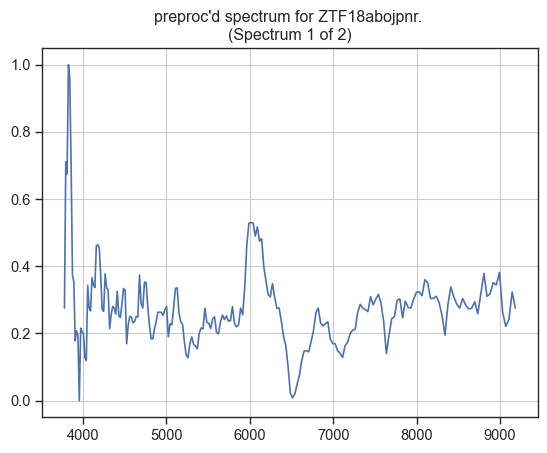

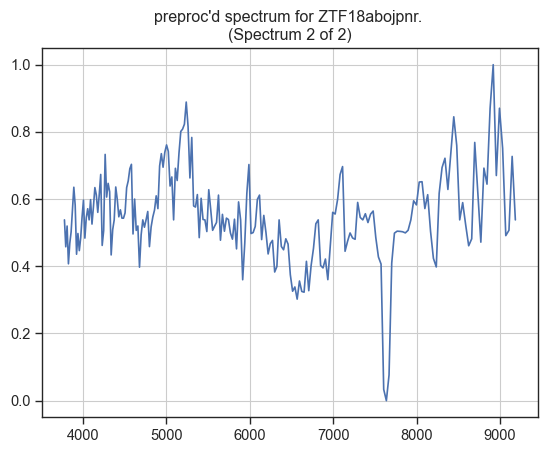

1 ZTF18acnmifq


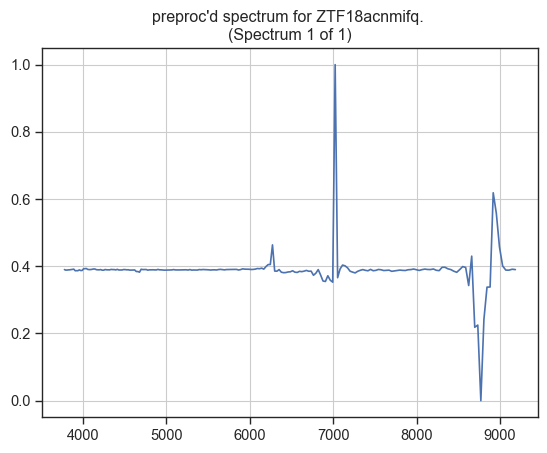

2 ZTF18acrcyqw


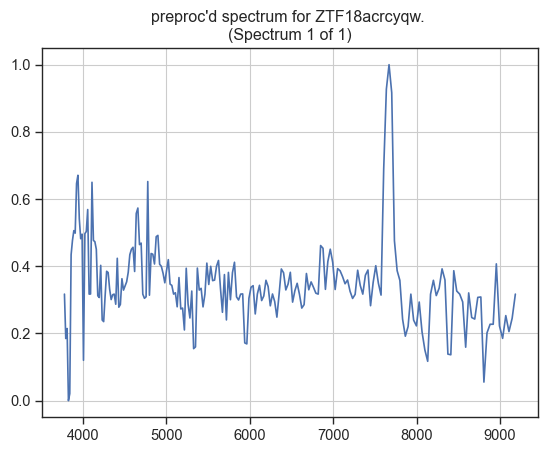

3 ZTF19aawethv


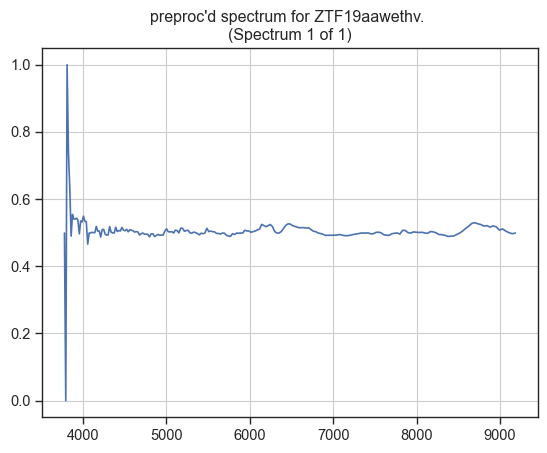

4 ZTF19abqmsnk


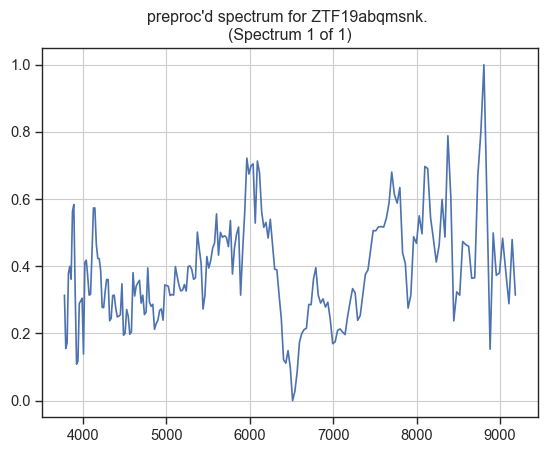

5 ZTF19abxtcio


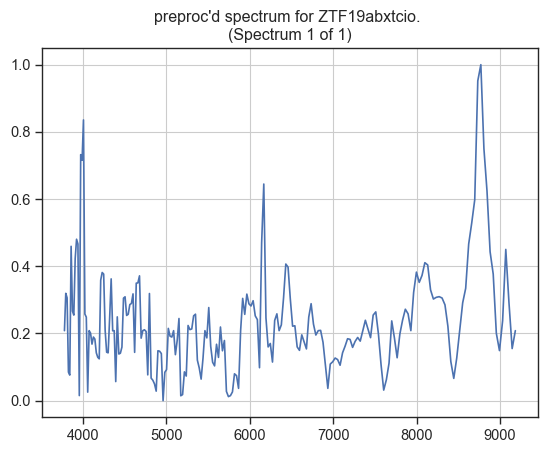

6 ZTF19aceshib


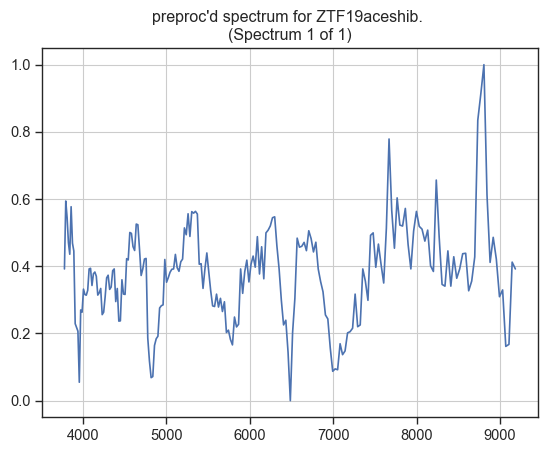

7 ZTF20adadlqm


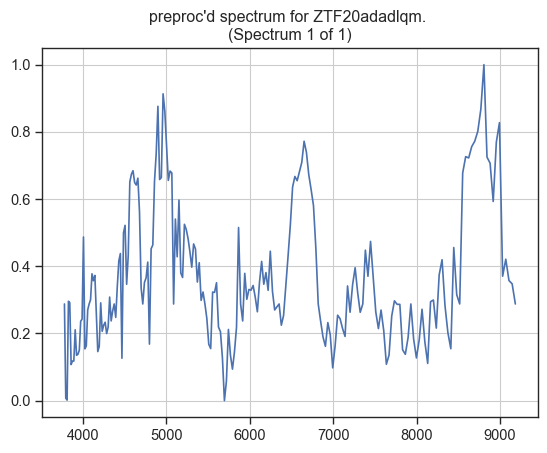

8 ZTF20acgiglu


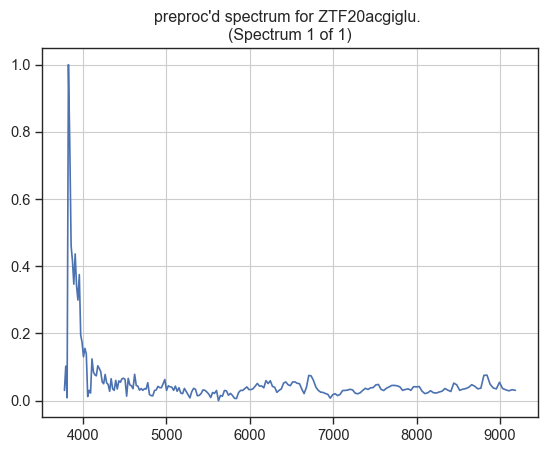

9 ZTF21aaxxmvs


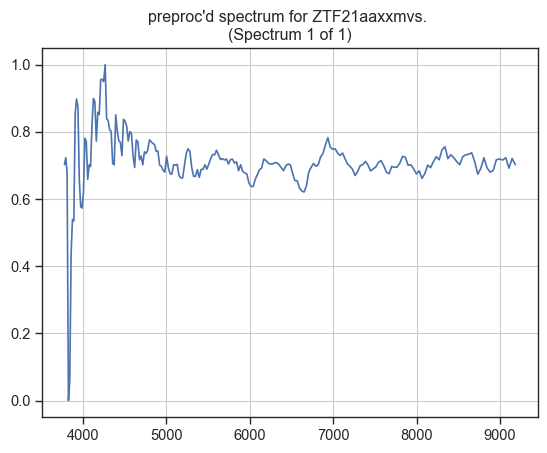

10 ZTF21aayfnjz


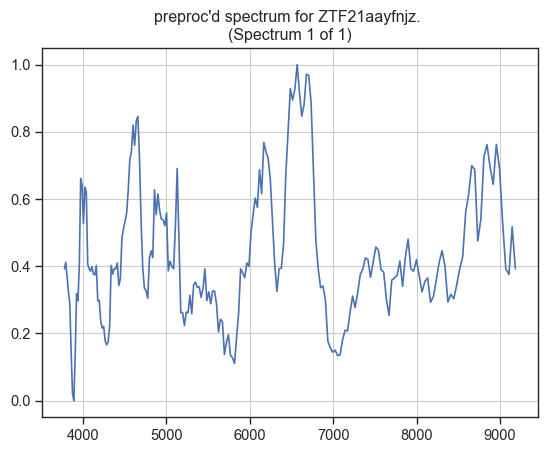

11 ZTF21abqvzjy


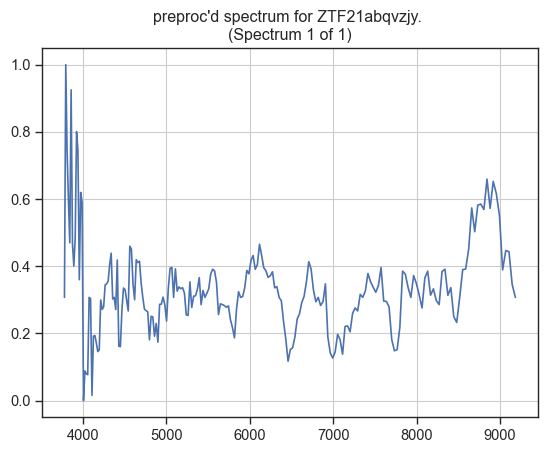

12 ZTF23aaawbsc


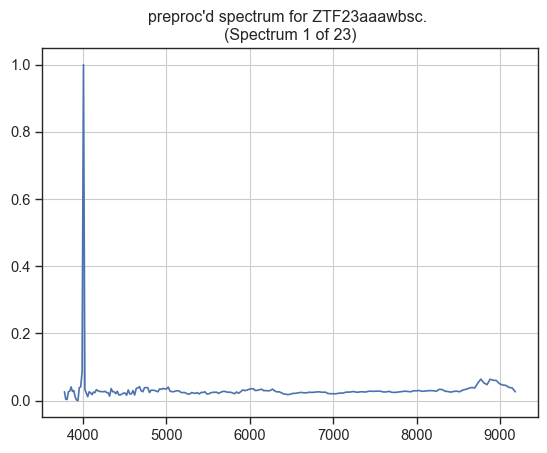

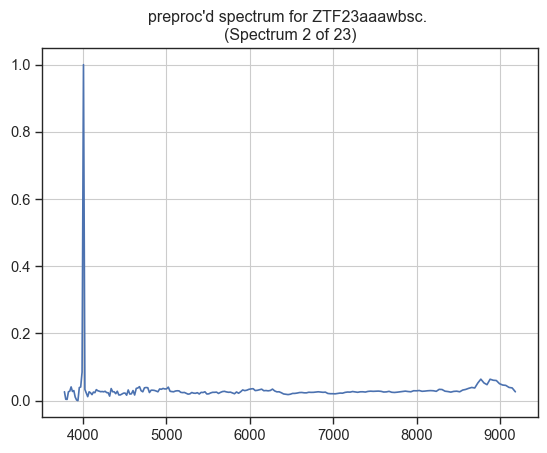

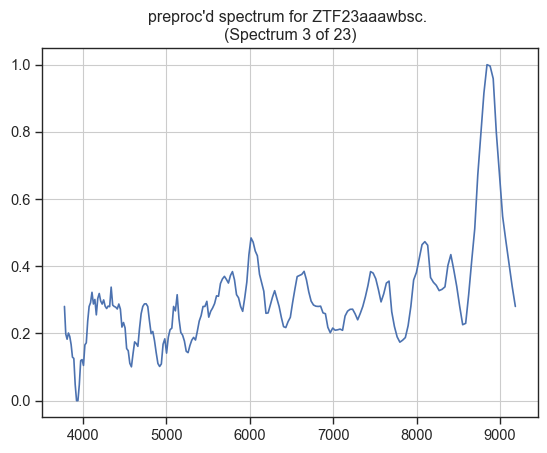

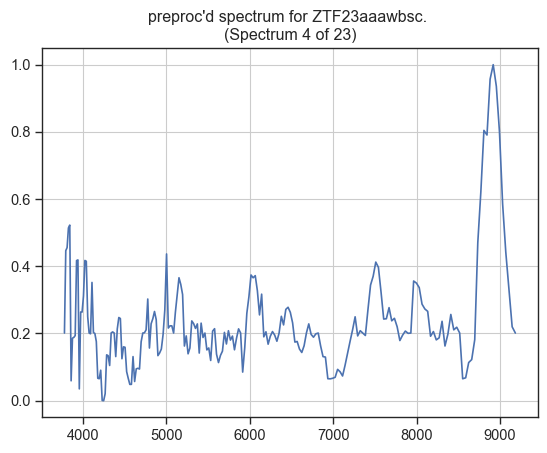

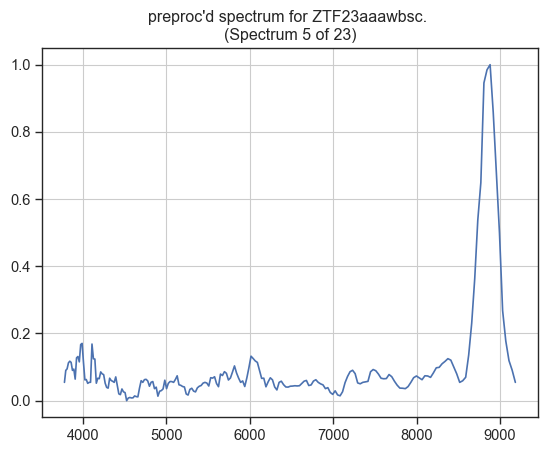

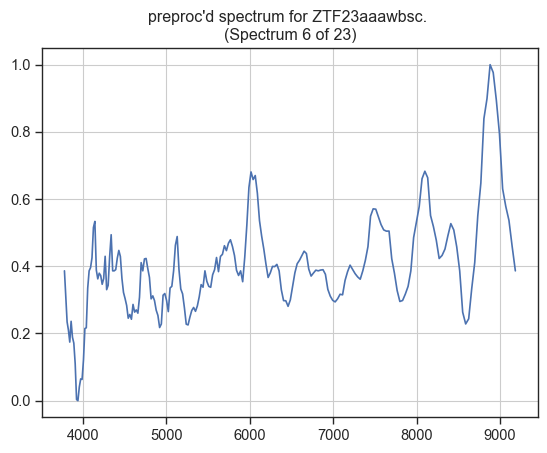

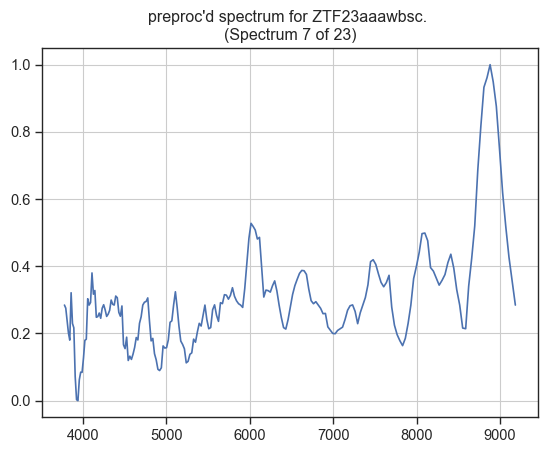

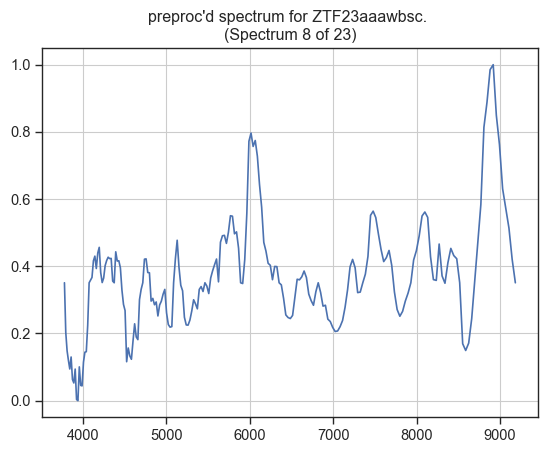

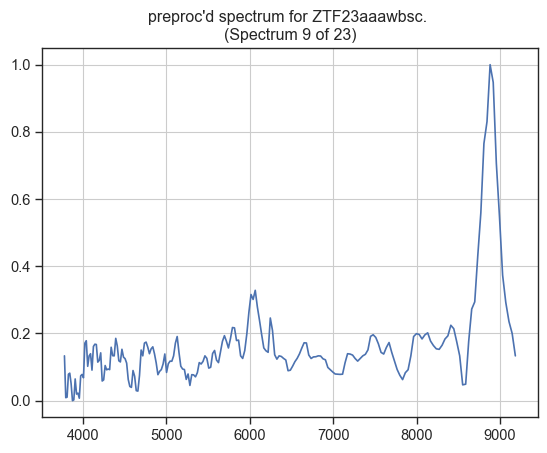

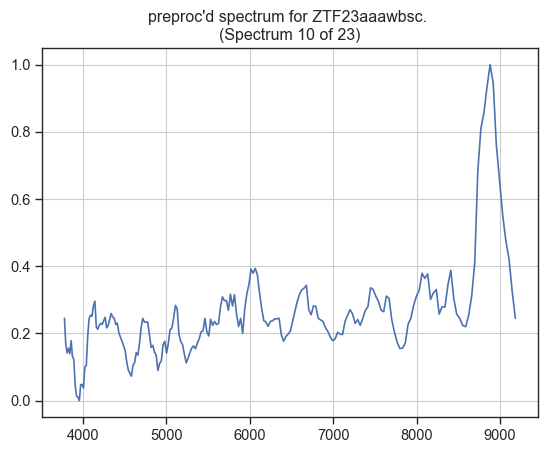

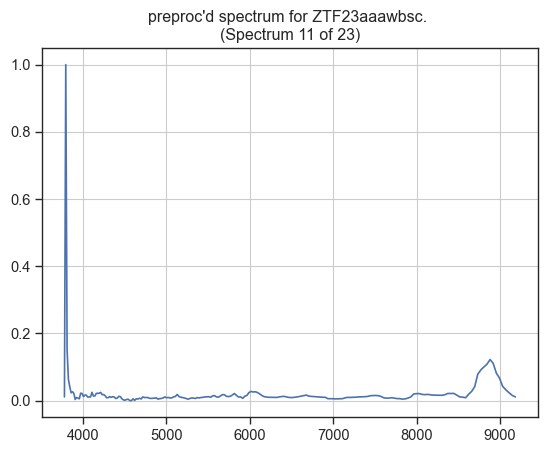

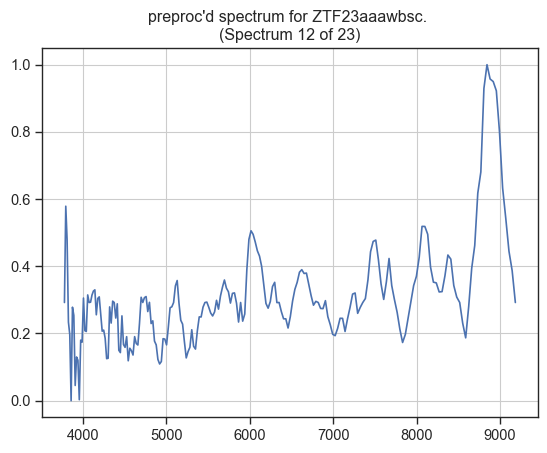

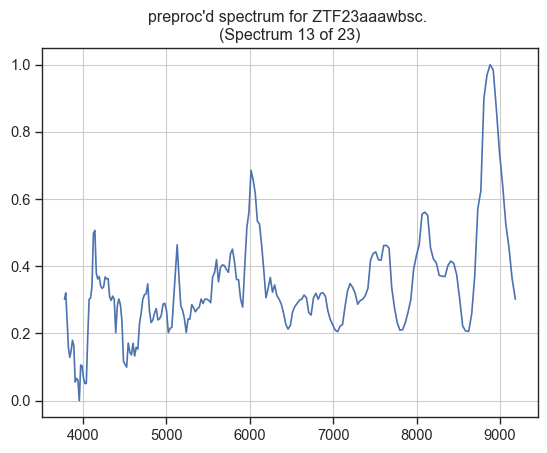

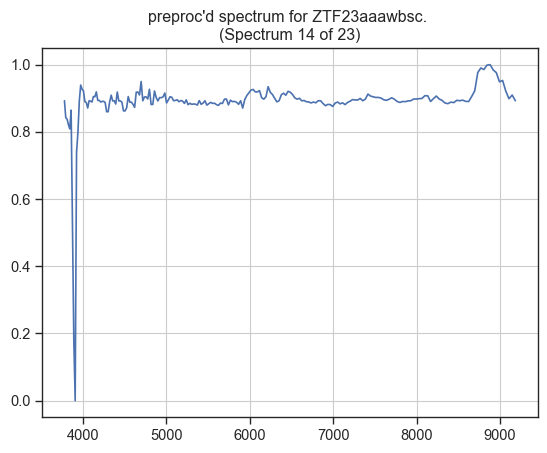

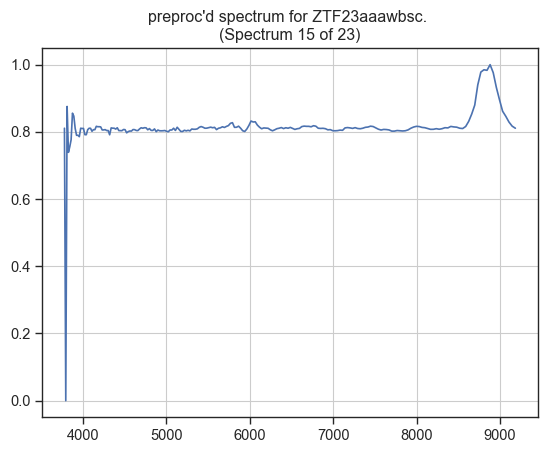

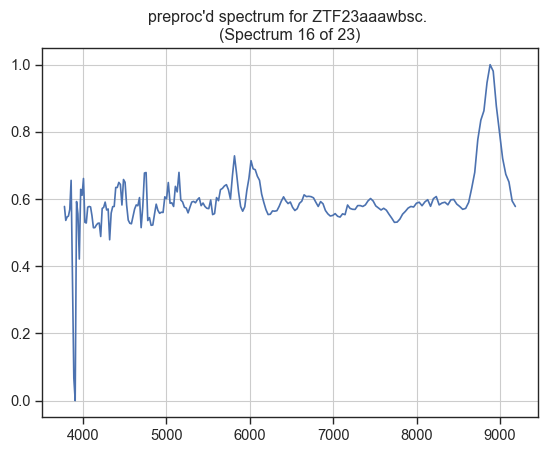

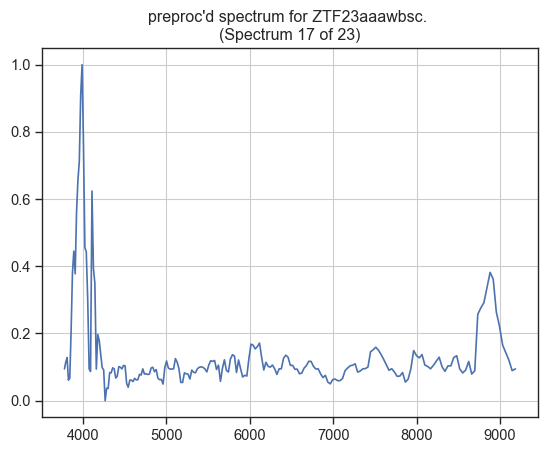

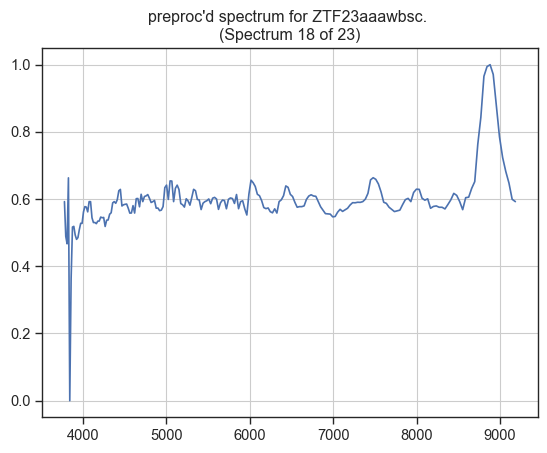

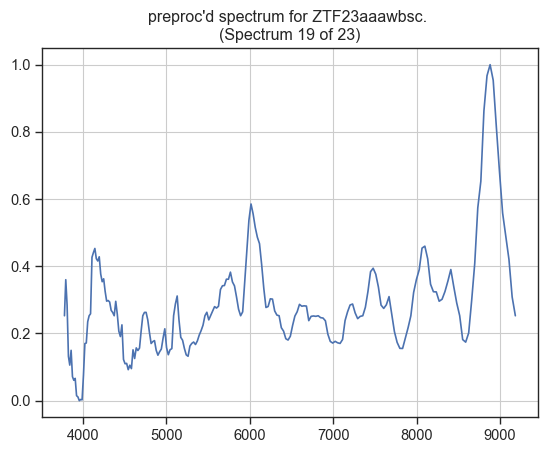

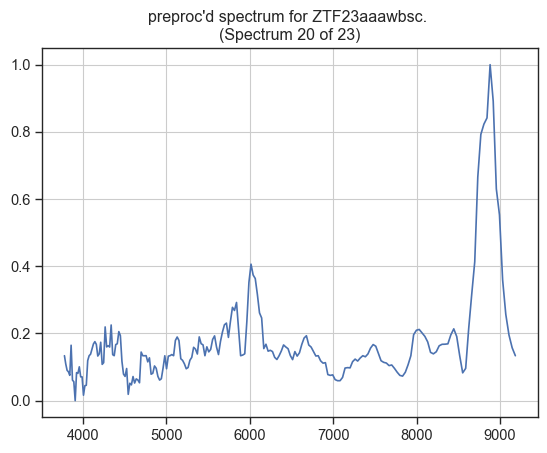

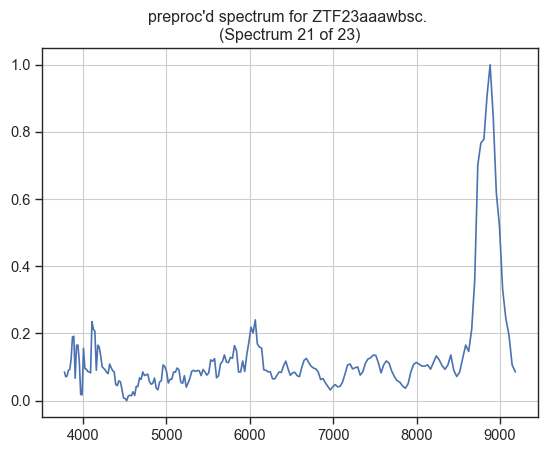

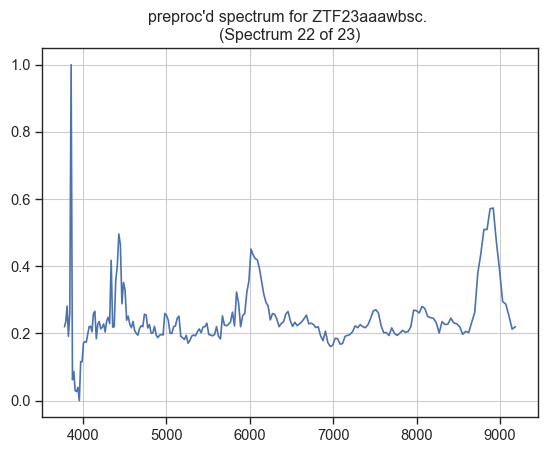

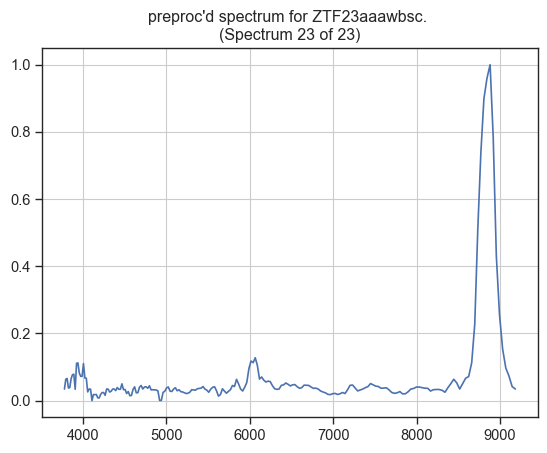

13 ZTF23aaialcw


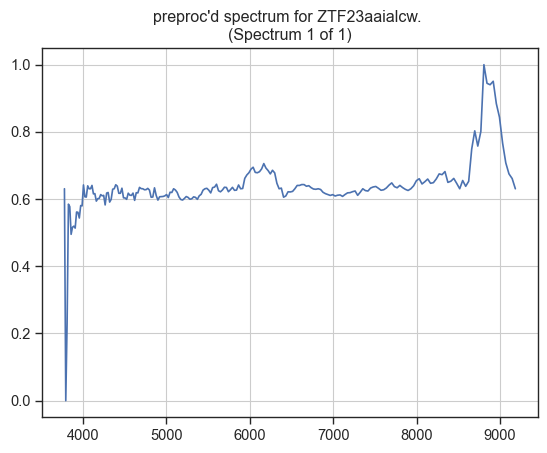

14 ZTF23aazjwtl


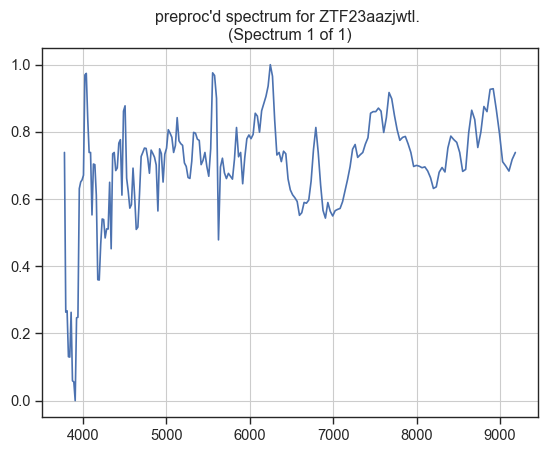

15 ZTF23aaaprhz


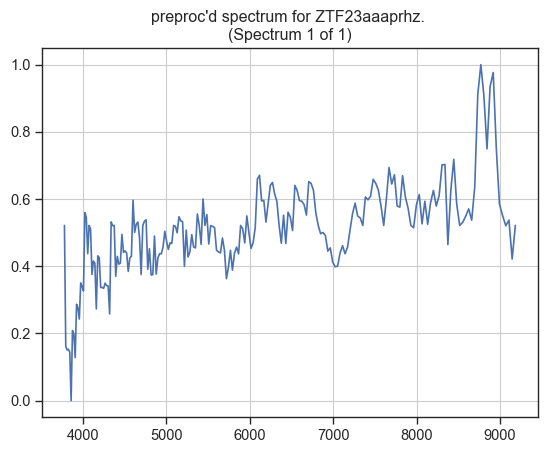

16 ZTF24abpdzvm


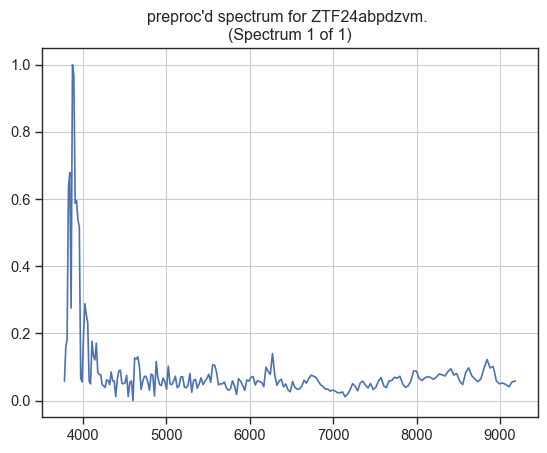

In [170]:
%matplotlib inline
for i in range(len(spectra_files_for_type)):
    sfiles = spectra_files_for_type[i]
    ztfname = ztf_names_ordered[i][0]
    print(i, ztfname)
    preproc_spectra4maven(sfiles, save=True, plot=True, savedir='./maven_data/spectra/', ztfname=ztfname)